In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
data = [
    ["Carhart-Harris_2012", "rest", 0.5, 15],
    ["Carhart-Harris_2012", "rest", 24, 15],
    ["Barrett_2020", "rest", 1, 24],
    ["Barrett_2020", "rest", 72, 24],
    ["Madsen_2019", "task", 2, 21],
    ["Madsen_2019", "task", 168, 21],
    ["Mason_2021", "rest", 6, 28],
    ["Mason_2021", "rest", 336, 28],
]

df = pd.DataFrame(
    data,
    columns=["study", "modality", "hours_post_dose", "n_subjects"]
)

df

,study,modality,hours_post_dose,n_subjects
0,Carhart-Harris_2012,rest,0.5,15
1,Carhart-Harris_2012,rest,24.0,15
2,Barrett_2020,rest,1.0,24
3,Barrett_2020,rest,72.0,24
4,Madsen_2019,task,2.0,21
5,Madsen_2019,task,168.0,21
6,Mason_2021,rest,6.0,28
7,Mason_2021,rest,336.0,28


In [4]:
def label_phase(h):
    if h <= 6:
        return "acute"
    elif h <= 72:
        return "early_postacute"
    else:
        return "late_postacute"

df["phase"] = df["hours_post_dose"].apply(label_phase)
df

,study,modality,hours_post_dose,n_subjects,phase
0,Carhart-Harris_2012,rest,0.5,15,acute
1,Carhart-Harris_2012,rest,24.0,15,early_postacute
2,Barrett_2020,rest,1.0,24,acute
3,Barrett_2020,rest,72.0,24,early_postacute
4,Madsen_2019,task,2.0,21,acute
5,Madsen_2019,task,168.0,21,late_postacute
6,Mason_2021,rest,6.0,28,acute
7,Mason_2021,rest,336.0,28,late_postacute


In [5]:
coverage = pd.crosstab(df["study"], df["phase"])
coverage["total_windows"] = coverage.sum(axis=1)
coverage = coverage.sort_values("total_windows", ascending=False)

coverage

phase,acute,early_postacute,late_postacute,total_windows
study,,,,
Barrett_2020,1,1,0,2
Carhart-Harris_2012,1,1,0,2
Madsen_2019,1,0,1,2
Mason_2021,1,0,1,2


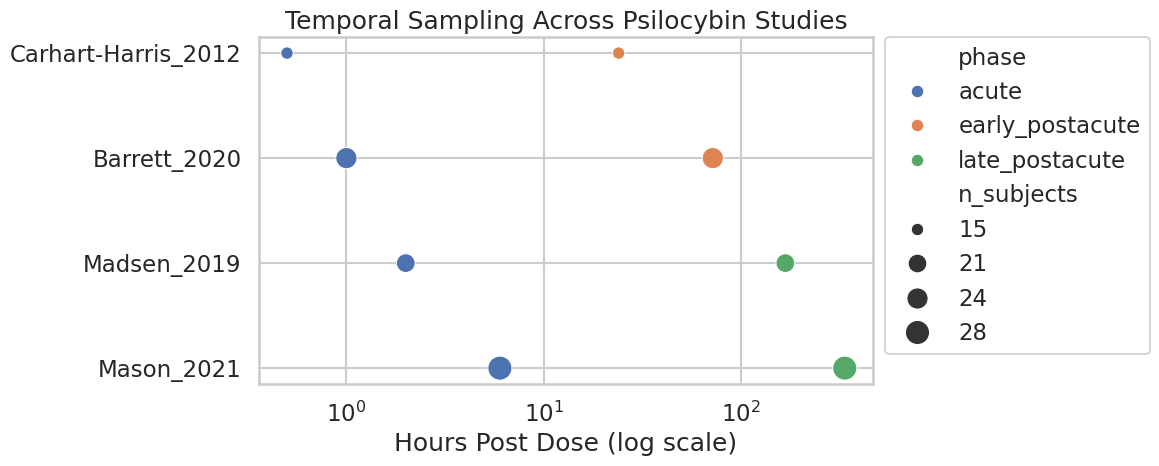

In [7]:
plt.figure(figsize=(12,5))

ax = sns.scatterplot(
    data=df,
    x="hours_post_dose",
    y="study",
    hue="phase",
    size="n_subjects",
    sizes=(80,300)
)

plt.xscale("log")
plt.xlabel("Hours Post Dose (log scale)")
plt.ylabel("")
plt.title("Temporal Sampling Across Psilocybin Studies")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.savefig("figures/01_timepoint_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
df.to_csv("outputs/01_harmonized_timepoints.csv", index=False)
coverage.to_csv("outputs/01_timepoint_coverage_table.csv")

print("Saved notebook outputs.")

Saved notebook outputs.
